# 🧠 Brain Tumor Segmentation — BraTS 2023 GLI

**Notebook huấn luyện 3D U-Net phân đoạn khối u não**

| Thông tin | Chi tiết |
|---|---|
| **Dataset** | BraTS 2023 GLI Challenge — Training Data |
| **Model** | 3D U-Net (MONAI) |
| **Framework** | PyTorch + MONAI |
| **Input** | 4 MRI modalities: T1n, T1c, T2w, T2f — shape `(4, 240, 240, 155)` |
| **Output** | Segmentation mask — 4 classes: Background / NCR / ED / ET |
| **Patch size** | 128 × 128 × 128 |

---

## 📋 Nội dung Notebook

1. Cài đặt thư viện
2. Imports & Config tập trung
3. Cấu hình đường dẫn dữ liệu
4. Khảo sát dữ liệu (EDA)
5. Dataset & DataLoader
6. Định nghĩa mô hình 3D U-Net
7. Training Loop (AMP + tqdm + Checkpoint)
8. Đồ thị Learning Curves
9. Đánh giá cuối cùng (Per-class Dice)
10. Export model (TorchScript & ONNX)

## 1. Cài Đặt Thư Viện

In [2]:
!pip install monai 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.5 MB/s eta 0:00:0000:01


## 2. Imports & Config Tập Trung


In [3]:
import os
import sys
import time
import json
import random
import hashlib
from pathlib import Path
from dataclasses import dataclass, asdict
from collections import defaultdict
from typing import Dict, List, Optional

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import monai
import monai.transforms as mt
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch
from monai.transforms import AsDiscrete




In [4]:
@dataclass
class Config:
    seed = 42
    val_split = 0.15                           # train/val
    modalities = ("t1n", "t1c", "t2w", "t2f")  # 4 chuỗi MRI

    in_channels = 4                            # 4 modal
    out_channels = 4                           # 0 bg, 1 NCR, 2 ED, 3 ET
    patch_size = (128, 128, 128)
    unet_features = (32, 64, 128, 256, 512)
    unet_strides = (2, 2, 2, 2)
    unet_res_units = 2

    max_epochs = 100
    lr = 2e-4
    weight_decay = 1e-5
    grad_clip = 1.0                          # chống loss bùng nổ
    val_interval = 2                         # validate mỗi 2 epoch
    sw_batch_size = 2

    batch_size = 1
    num_workers = 2
    num_samples = 2                          # crop mỗi ảnh 2 patch

    ckpt_dir = "checkpoints"
    models_dir = "models"

CFG = Config()

CLASS_NAMES = {0: "Background", 1: "NCR", 2: "ED", 3: "ET"}
LABEL_REMAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3}  # gom label 4 về 3 (ET)


def set_seed(seed=CFG.seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True   # chạy lại ra kết quả y hệt
    torch.backends.cudnn.benchmark = False      # tắt chọn thuật toán ngẫu nhiên

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"MONAI  : {monai.__version__} | PyTorch: {torch.__version__}")

Device : cuda
GPU    : Tesla T4
MONAI  : 1.6.0 | PyTorch: 2.11.0+cu128


## 3. Cấu Hình Đường Dẫn Dữ Liệu BraTS 2023

In [7]:
# Mount Drive 
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

# Ưu tiên env var, fallback các đường dẫn Drive phổ biến
DATA_ROOT = Path(
    os.environ.get("BRATS_DATA_ROOT")
    or os.environ.get("DATA_ROOT")
    or "/content/drive/MyDrive/BraTS2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
)


data_root = Path(DATA_ROOT)
if data_root.exists() and any(d.is_dir() for d in data_root.iterdir()):
    all_cases = sorted(d.name for d in data_root.iterdir() if d.is_dir())
    print(f"Dataset: {len(all_cases)} cases → {all_cases[:3]}")
else:
    print("Không tìm thấy dataset. Kiểm tra đường dẫn hoặc mount Drive.")
    all_cases = []

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: 1251 cases → ['BraTS-GLI-00000-000', 'BraTS-GLI-00002-000', 'BraTS-GLI-00003-000']


## 4. Khảo Sát Dữ Liệu (EDA)

Trước khi train, ta kiểm tra:
- Cấu trúc file: shape, spacing, dtype
- Phân bố nhãn (label distribution)
- Tính toàn vẹn dữ liệu (integrity check)
- Visualization mẫu

In [12]:
#Đọc thông tin 1 case mẫu 
if all_cases:
    case_id = all_cases[0]
    case_dir = DATA_ROOT / case_id

    print(f"CASE MẪU: {case_id}\n")

    for mod in CFG.modalities:
        nii = nib.load(case_dir / f"{case_id}-{mod}.nii.gz")
        arr = nii.get_fdata()
        spacing = np.abs(np.diag(nii.affine)[:3])
        print(f"  {mod.upper():5s} shape={arr.shape} | "
              f"range=[{arr.min():.1f}, {arr.max():.1f}] | "
              f"spacing={spacing.round(2)} mm")

    seg = nib.load(case_dir / f"{case_id}-seg.nii.gz").get_fdata().astype(np.int32)
    print(f"\n  PHÂN BỐ NHÃN: {np.unique(seg)}")
    for v in np.unique(seg):
        pct = 100.0 * (seg == v).sum() / seg.size
        print(f"    Label {v} ({CLASS_NAMES.get(v, '??'):10s}): {pct:.3f}%")
else:
    print("Chưa có case nào để khảo sát.")


CASE MẪU: BraTS-GLI-00000-000

  T1N   shape=(240, 240, 155) | range=[0.0, 2023.0] | spacing=[1. 1. 1.] mm
  T1C   shape=(240, 240, 155) | range=[0.0, 12343.0] | spacing=[1. 1. 1.] mm
  T2W   shape=(240, 240, 155) | range=[0.0, 2421.0] | spacing=[1. 1. 1.] mm
  T2F   shape=(240, 240, 155) | range=[0.0, 2934.0] | spacing=[1. 1. 1.] mm

  PHÂN BỐ NHÃN: [0 1 2 3]
    Label 0 (Background): 99.358%
    Label 1 (NCR       ): 0.131%
    Label 2 (ED        ): 0.144%
    Label 3 (ET        ): 0.367%


## 4.1. Giải thích kết quả khảo sát dữ liệu

### 1. Shape `(240, 240, 155)` — ý nghĩa

Mỗi chuỗi MRI là một khối dữ liệu 3D gồm:

- `240 × 240`: kích thước của mỗi lát cắt ngang (axial).
- `155`: số lát cắt xếp chồng theo chiều sâu.

Cả bốn chuỗi MRI đều có cùng shape nên chúng nằm trong cùng một không gian 3D và các voxel tương ứng với nhau. Vì vậy, mô hình có thể nhận bốn chuỗi này như bốn kênh đầu vào, tương tự như ảnh màu có ba kênh RGB. Bốn kênh trong bài toán này là `T1n`, `T1c`, `T2w` và `T2f`.

### 2. Spacing `[1, 1, 1]` mm

Spacing cho biết khoảng cách giữa hai voxel liền kề theo ba trục không gian. Với spacing bằng `1 mm` ở cả ba chiều:

- Thể tích của một voxel là `1 × 1 × 1 = 1 mm³`.
- Thể tích khối u có thể được tính theo công thức:

$$
\text{Thể tích (cm³)} = \frac{\text{số voxel của khối u} \times (s_x \times s_y \times s_z)}{1000}
$$

Trong đó, `s_x`, `s_y` và `s_z` là spacing theo ba chiều, tính bằng mm. Với spacing `[1, 1, 1]`, công thức đơn giản thành:

$$
\text{Thể tích (cm³)} = \frac{\text{số voxel của khối u}}{1000}
$$

### 3. Range — vì sao khác nhau giữa các chuỗi

Giá trị voxel biểu thị cường độ sáng tương đối và không có cùng một đơn vị chuẩn giữa các chuỗi MRI. Mỗi modality có cách thu nhận tín hiệu khác nhau nên range cũng khác nhau:

| Chuỗi | Range | Ý nghĩa khái quát |
|---|---:|---|
| T1n | `0 → 2023` | T1 không tiêm thuốc tương phản |
| T1c | `0 → 12343` | T1 có tiêm thuốc tương phản |
| T2w | `0 → 2421` | T2-weighted |
| T2f | `0 → 2934` | T2-FLAIR |

Range của `T1c` lớn hơn nhiều so với các chuỗi còn lại. Nếu đưa dữ liệu thô trực tiếp vào mô hình, modality có range lớn có thể chi phối quá trình học. Vì vậy, cần chuẩn hóa dữ liệu trước khi huấn luyện. Trong notebook này, mỗi modality được chuẩn hóa bằng z-score trên vùng não:

$$
\hat{x} = \frac{x - \mu}{\sigma + \epsilon}
$$

### 4. Phân bố nhãn

Các nhãn trong segmentation mask gồm:

- **Label 0 — Background:** nền, không thuộc vùng tổn thương.
- **Label 1 — NCR:** vùng u hoại tử.
- **Label 2 — ED:** vùng phù não.
- **Label 3 — ET:** vùng u tăng tín hiệu sau tiêm thuốc tương phản.

Trong case mẫu, tỷ lệ voxel của các vùng tổn thương là:

| Nhãn | Thành phần | Tỷ lệ voxel |
|---:|---|---:|
| 0 | Background | khoảng `99.36%` |
| 1 | NCR | `0.131%` |
| 2 | ED | `0.144%` |
| 3 | ET | `0.367%` |

### 5. Những điểm quan trọng rút ra

1. **Mất cân bằng lớp rất lớn:** tổng ba lớp tổn thương chỉ chiếm khoảng `0.64%` tổng số voxel, trong khi background chiếm gần như toàn bộ thể tích. Nếu chỉ dùng accuracy, mô hình có thể đạt điểm cao bằng cách dự đoán background cho phần lớn voxel nhưng vẫn phân đoạn khối u rất kém. Vì vậy, notebook sử dụng `DiceCELoss` và đánh giá bằng Dice score.

2. **Vùng tổn thương có kích thước nhỏ:** khối u chiếm dưới `1%` thể tích ảnh. Do đó, huấn luyện trên các patch tập trung vào vùng có tổn thương, chẳng hạn patch `128³`, giúp mô hình có nhiều cơ hội quan sát thông tin quan trọng hơn so với việc chỉ xử lý toàn bộ ảnh `240 × 240 × 155`.

3. **Mapping nhãn:** dữ liệu đang sử dụng bốn lớp `0–3`, tương ứng với `Background`, `NCR`, `ED` và `ET`. Mapping `4 → 3` trong `LABEL_REMAP` vẫn được giữ để tương thích với những trường hợp dữ liệu có label `4`.

---

### Tóm tắt

- Bốn modality có cùng kích thước `240 × 240 × 155` nên có thể ghép thành input bốn kênh.
- Spacing `1 mm` theo cả ba chiều cho phép tính thể tích từ số lượng voxel.
- Range giữa các modality khác nhau đáng kể nên cần normalize trước khi train.
- Tổn thương chiếm dưới `1%` số voxel, đây là lý do sử dụng `DiceCELoss` và random crop patch `128³`.

In [ ]:
# ── 4.2 Integrity check — quét tất cả cases ──────────────────
if all_cases:
    ALL_MODS = list(CFG.modalities) + ["seg"]
    missing  = {}

    for case_id in tqdm(all_cases, desc="Integrity check"):
        case_dir = DATA_ROOT / case_id
        absent = [m for m in ALL_MODS
                  if not (case_dir / f"{case_id}-{m}.nii.gz").exists()]
        if absent:
            missing[case_id] = absent

    print(f"\n Integrity check xong: {len(all_cases)} cases")
    print(f"   Cases bị thiếu file: {len(missing)}")
    if missing:
        for cid, mods in list(missing.items())[:5]:
            print(f"   ⚠️ {cid}: thiếu {mods}")
else:
    print("Chưa có case nào để kiểm tra.")

Integrity check:   0%|          | 0/1251 [00:00<?, ?it/s]


 Integrity check xong: 1251 cases
   Cases bị thiếu file: 0


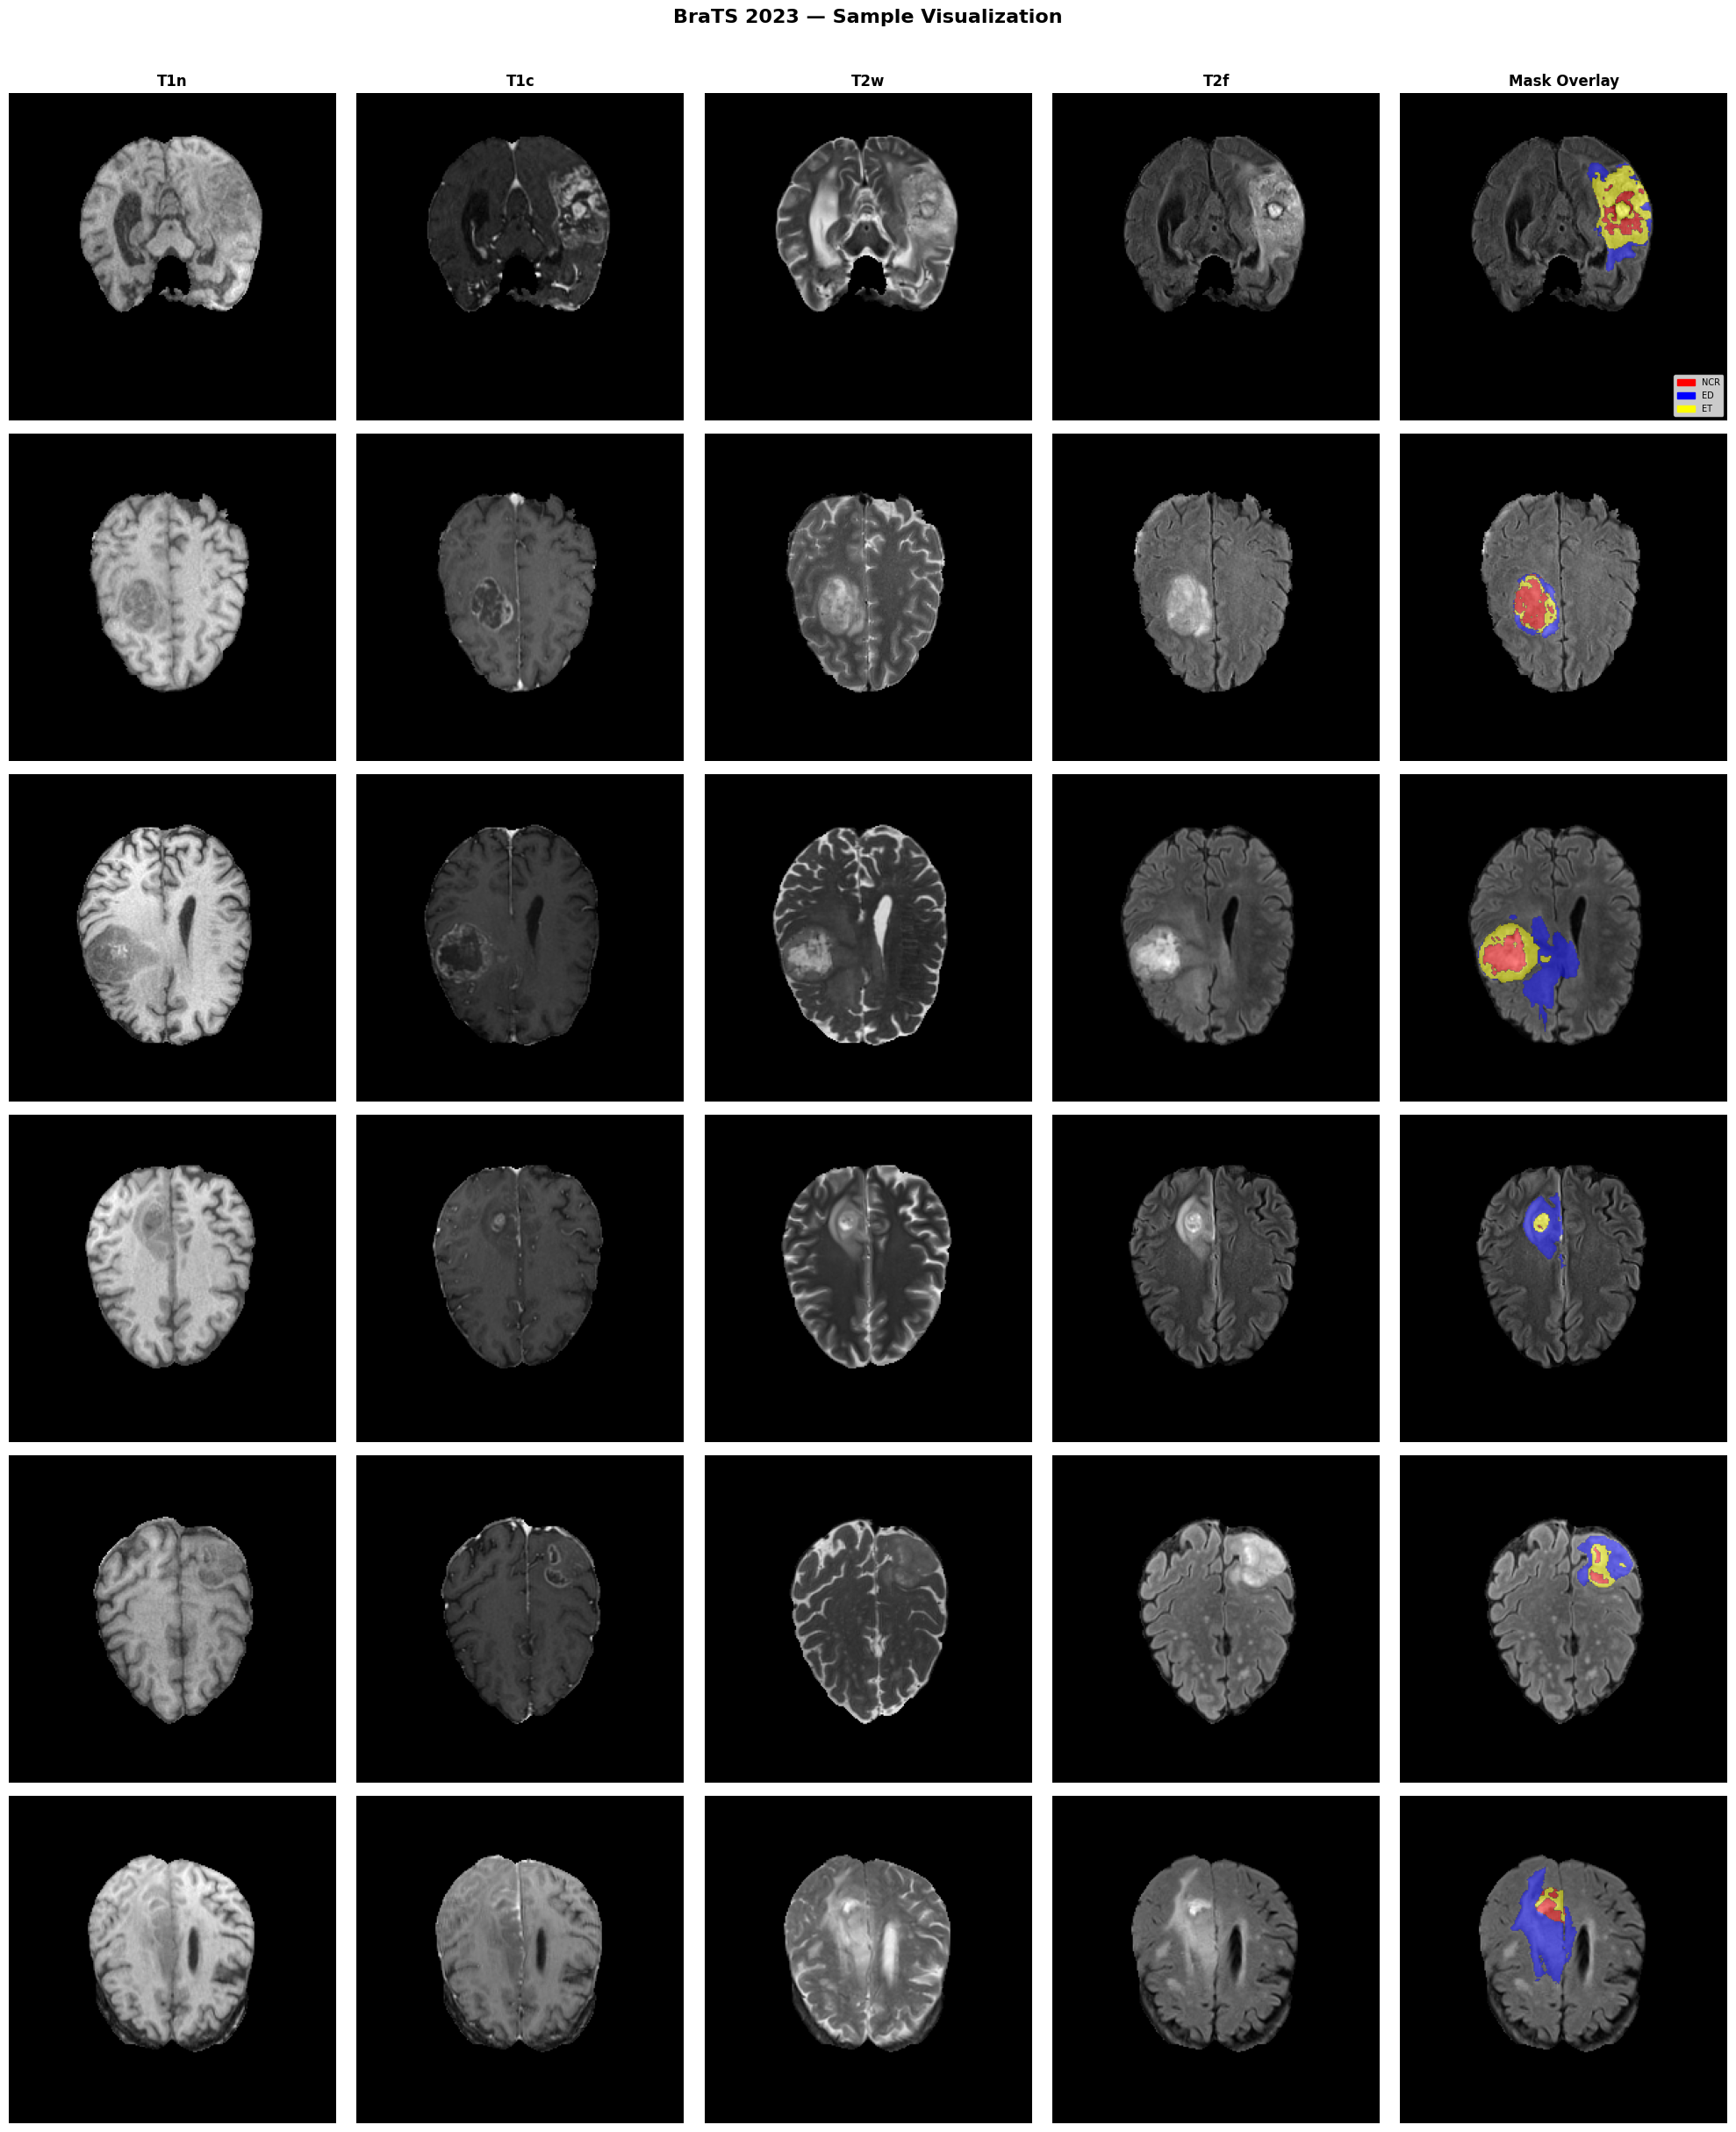

 Are you likeĐã hiển thị 6 cases mẫu.


In [ ]:
# ── 4.3 Visualization — 6 cases mẫu ─────────────────────────
if all_cases:
    rng       = np.random.default_rng(CFG.seed)
    vis_cases = rng.choice(all_cases, size=min(6, len(all_cases)), replace=False)

    fig, axes = plt.subplots(len(vis_cases), 5, figsize=(20, 4 * len(vis_cases)))
    fig.suptitle("BraTS 2023 — Sample Visualization", fontsize=16, fontweight="bold", y=1.01)

    col_titles = ["T1n", "T1c", "T2w", "T2f", "Mask Overlay"]
    label_colors = {1: "red", 2: "blue", 3: "yellow"}

    for row, cid in enumerate(vis_cases):
        case_dir = DATA_ROOT / cid
        try:
            vols = {mod: nib.load(case_dir / f"{cid}-{mod}.nii.gz").get_fdata()
                    for mod in CFG.modalities}
            seg  = nib.load(case_dir / f"{cid}-seg.nii.gz").get_fdata().astype(np.int32)

            tumor_per_slice = (seg > 0).sum(axis=(0, 1))
            z = int(np.argmax(tumor_per_slice)) if tumor_per_slice.max() > 0 \
                else seg.shape[2] // 2

            for col, mod in enumerate(CFG.modalities):
                ax = axes[row, col]
                ax.imshow(np.rot90(vols[mod][:, :, z]), cmap="gray")
                ax.axis("off")
                if row == 0:
                    ax.set_title(col_titles[col], fontweight="bold", fontsize=12)

            # Mask overlay
            ax = axes[row, 4]
            ax.imshow(np.rot90(vols["t2f"][:, :, z]), cmap="gray")
            seg_slice = seg[:, :, z]
            for label_val, color in label_colors.items():
                masked = np.ma.masked_where(seg_slice != label_val, seg_slice)
                ax.imshow(np.rot90(masked), cmap=plt.cm.colors.ListedColormap([color]),
                          alpha=0.5, vmin=label_val, vmax=label_val)
            ax.axis("off")
            if row == 0:
                ax.set_title(col_titles[4], fontweight="bold", fontsize=12)
                patches = [mpatches.Patch(color=c, label=CLASS_NAMES[l])
                           for l, c in label_colors.items()]
                ax.legend(handles=patches, loc="lower right", fontsize=7)

            axes[row, 0].set_ylabel(f"{cid}\n(z={z})", fontsize=8, rotation=0,
                                     labelpad=70, va="center")
        except Exception as e:
            for col in range(5):
                axes[row, col].axis("off")
            axes[row, 2].text(0.5, 0.5, f"Lỗi:\n{e}",
                              ha="center", va="center", color="red", fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f" Are you likeĐã hiển thị {len(vis_cases)} cases mẫu.")
else:
    print("Chưa có case nào để visualize.")

## 5. Dataset & DataLoader

**`BraTSDataset3D`** đọc 4 MRI modalities + mask, áp dụng z-score normalization theo vùng não.

In [ ]:
# ── Train / Val Split ────────────────────────────────────────
train_cases, val_cases = train_test_split(
    all_cases,
    test_size=CFG.val_split,
    random_state=CFG.seed
)
print(f"  Split: Train={len(train_cases)} | Val={len(val_cases)}")

  Split: Train=1063 | Val=188


In [ ]:
class BraTSDataset3D(Dataset):
    """PyTorch Dataset cho BraTS 2023 GLI.

    Đọc 4 MRI modalities + segmentation mask.
    Áp dụng z-score normalization theo vùng não (brain mask).
    Remaps label ET(4) → ET(3).

    Args:
        data_root  : Đường dẫn thư mục gốc chứa các case.
        case_ids   : Danh sách ID các case.
        transforms : MONAI Compose transforms (optional).
    """

    def __init__(self, data_root: Path, case_ids: List[str],
                 transforms=None) -> None:
        self.data_root  = Path(data_root)
        self.case_ids   = case_ids
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.case_ids)

    def _load_and_normalize(self, fpath: Path) -> np.ndarray:
        """Load NIfTI + z-score normalization theo vùng não."""
        arr  = nib.load(fpath).get_fdata().astype(np.float32)
        mask = arr > 0
        if mask.any():
            arr[mask] = (arr[mask] - arr[mask].mean()) / (arr[mask].std() + 1e-8)
        return arr

    def _remap_label(self, seg: np.ndarray) -> np.ndarray:
        """Remap raw BraTS labels: ET(4) -> ET(3)."""
        remapped = np.zeros_like(seg)
        for src, dst in LABEL_REMAP.items():
            remapped[seg == src] = dst
        return remapped

    def __getitem__(self, idx: int) -> Dict:
        case_id  = self.case_ids[idx]
        case_dir = self.data_root / case_id

        # Load & normalize 4 modalities
        channels = [
            self._load_and_normalize(case_dir / f"{case_id}-{mod}.nii.gz")
            for mod in CFG.modalities
        ]
        image = np.stack(channels, axis=0)  # (4, H, W, D)

        # Load & remap segmentation mask
        seg_path = case_dir / f"{case_id}-seg.nii.gz"
        label    = nib.load(seg_path).get_fdata().astype(np.int16)
        label    = np.expand_dims(label, axis=0)

        sample = {"image": image, "label": label}
        if self.transforms:
            sample = self.transforms(sample)
        return sample

In [ ]:
# ── MONAI Transforms ─────────────────────────────────────────
train_transforms = mt.Compose([
    # Random crop 128³ — ưu tiên vùng có tumor
    mt.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=CFG.patch_size,
        pos=1.0, neg=1.0,
        num_samples=CFG.num_samples,
        image_key="image"
    ),
    # Flip ngẫu nhiên theo 3 trục
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    # Xoay 90 độ ngẫu nhiên
    mt.RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    # Augmentation intensity
    mt.RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    mt.RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
    mt.RandGaussianNoised(keys="image", prob=0.2, std=0.01),
    mt.EnsureTyped(keys=["image", "label"]),
])

val_transforms = mt.Compose([
    mt.EnsureTyped(keys=["image", "label"]),
])

# ── Datasets ─────────────────────────────────────────────────
train_dataset = BraTSDataset3D(DATA_ROOT, train_cases, transforms=train_transforms)
val_dataset   = BraTSDataset3D(DATA_ROOT, val_cases,   transforms=val_transforms)

# ── DataLoaders ──────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=CFG.batch_size, shuffle=True,
    num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=CFG.batch_size, shuffle=False,
    num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True
)

print(f" DataLoaders sẵn sàng")
print(f"   Train : {len(train_dataset)} cases")
print(f"   Val   : {len(val_dataset)} cases")

 DataLoaders sẵn sàng
   Train : 1063 cases
   Val   : 188 cases


## 6. Định Nghĩa Mô Hình — 3D U-Net

- **Input**: `(B, 4, 128, 128, 128)` — 4 MRI modalities
- **Output**: `(B, 4, 128, 128, 128)` — 4 classes (Background / NCR / ED / ET)
- **Architecture**: Encoder `[32→64→128→256→512]` + Decoder (skip connections)

In [ ]:
def build_unet() -> nn.Module:
    """Xây dựng 3D U-Net chuẩn MONAI.

    Returns:
        nn.Module: Mô hình 3D U-Net chưa được đưa lên device.
    """
    return UNet(
        spatial_dims=3,
        in_channels=CFG.in_channels,
        out_channels=CFG.out_channels,
        channels=CFG.unet_features,
        strides=CFG.unet_strides,
        num_res_units=CFG.unet_res_units,
        norm="BATCH",
    )


# ── Khởi tạo model ───────────────────────────────────────────
model = build_unet().to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f" Model     : {model.__class__.__name__}")
print(f"   Encoder  : {list(CFG.unet_features)}")
print(f"   Params   : {trainable_params:,} trainable / {total_params:,} total")
print(f"   Device   : {device}")

 Model     : UNet
   Encoder  : [32, 64, 128, 256, 512]
   Params   : 19,230,769 trainable / 19,230,769 total
   Device   : cuda


## 7. Training Loop

**Các kỹ thuật sử dụng:**
| Kỹ thuật | Mục đích |
|---|---|
| `DiceCELoss` | Xử lý class imbalance (tumor rất nhỏ ~0.6% voxel) |
| `AdamW` | Optimizer tốt hơn Adam cho medical imaging |
| `CosineAnnealingLR` | Learning rate schedule — giảm mượt mà |
| `AMP` (mixed precision) | Tăng tốc ~2x trên T4/A100, tiết kiệm VRAM |
| Gradient Clipping | Tránh gradient exploding |
| Sliding Window Inference | Inference đúng trên ảnh 240³ |
| Per-class Dice | Báo cáo NCR/ED/ET riêng biệt |

In [ ]:
# ── Checkpoint paths ─────────────────────────────────────────
CKPT_DIR  = Path(CFG.ckpt_dir);   CKPT_DIR.mkdir(exist_ok=True)
BEST_CKPT = CKPT_DIR / "unet_best.pth"
LAST_CKPT = CKPT_DIR / "unet_last.pth"
HIST_FILE = CKPT_DIR / "history.json"

# ── Loss ─────────────────────────────────────────────────────
loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)

# ── Optimizer ────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG.lr,
    weight_decay=CFG.weight_decay
)

# ── Scheduler ────────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG.max_epochs
)

# ── AMP Scaler ───────────────────────────────────────────────
scaler = GradScaler()

# ── Metrics ──────────────────────────────────────────────────
# Per-class Dice (NCR / ED / ET)
dice_metric_per_class = DiceMetric(
    include_background=False, reduction="mean_batch"
)
# Mean Dice (trung bình 3 classes)
dice_metric_mean = DiceMetric(
    include_background=False, reduction="mean"
)

post_pred  = AsDiscrete(argmax=True, to_onehot=CFG.out_channels)
post_label = AsDiscrete(to_onehot=CFG.out_channels)

# ── History ──────────────────────────────────────────────────
history = {
    "train_loss" : [],
    "val_dice"   : [],
    "val_dice_ncr": [],
    "val_dice_ed" : [],
    "val_dice_et" : [],
    "lr"         : [],
}
best_dice = -1.0

print(f" Config Training:")
print(f"   Epochs       : {CFG.max_epochs}")
print(f"   LR           : {CFG.lr}")
print(f"   Val interval : mỗi {CFG.val_interval} epoch")
print(f"   AMP          : {' Bật' if torch.cuda.is_available() else '❌ Tắt (không có GPU)'}")
print(f"   Checkpoint   : {CKPT_DIR.resolve()}")

 Config Training:
   Epochs       : 100
   LR           : 0.0002
   Val interval : mỗi 2 epoch
   AMP          :  Bật
   Checkpoint   : /content/checkpoints


/tmp/ipykernel_3536/4229661662.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
# ============================================================
#  TRAINING LOOP CHÍNH
# ============================================================
print(f" Bắt đầu training 3D U-Net trên {str(device).upper()}")
print("-" * 60)

epoch_pbar = tqdm(range(1, CFG.max_epochs + 1), desc="Training", unit="epoch")

for epoch in epoch_pbar:
    # ── TRAIN PHASE ──────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    t0 = time.time()

    for batch in train_loader:
        # RandCropByPosNegLabeld với num_samples > 1 trả về list
        if isinstance(batch, list):
            images = torch.cat([b["image"] for b in batch], dim=0).to(device)
            labels = torch.cat([b["label"] for b in batch], dim=0).to(device)
        else:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

        optimizer.zero_grad()

        # AMP — Mixed Precision
        with autocast():
            outputs = model(images)
            loss    = loss_fn(outputs, labels)

        scaler.scale(loss).backward()

        # Gradient Clipping
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.grad_clip)

        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(epoch_loss)
    history["lr"].append(current_lr)

    dt = time.time() - t0
    epoch_pbar.set_postfix({"loss": f"{epoch_loss:.4f}", "lr": f"{current_lr:.2e}"})
    print(f"Epoch {epoch:3d}/{CFG.max_epochs} | Loss: {epoch_loss:.4f} "
                f"| LR: {current_lr:.2e} | Time: {dt:.1f}s")

    # ── VALIDATION PHASE ─────────────────────────────────────
    if epoch % CFG.val_interval == 0:
        model.eval()
        t0_val = time.time()

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device)
                labels = batch["label"].to(device)

                # Sliding window inference cho ảnh 240³
                val_out = sliding_window_inference(
                    inputs=images,
                    roi_size=CFG.patch_size,
                    sw_batch_size=CFG.sw_batch_size,
                    predictor=model
                )

                preds_list  = [post_pred(i)  for i in decollate_batch(val_out)]
                labels_list = [post_label(i) for i in decollate_batch(labels)]

                dice_metric_per_class(y_pred=preds_list, y=labels_list)
                dice_metric_mean(y_pred=preds_list, y=labels_list)

        # Tổng hợp metrics
        per_class = dice_metric_per_class.aggregate()  # [ncr, ed, et]
        mean_dice = dice_metric_mean.aggregate().item()
        dice_metric_per_class.reset()
        dice_metric_mean.reset()

        dice_ncr = per_class[0].item()
        dice_ed  = per_class[1].item()
        dice_et  = per_class[2].item()

        history["val_dice"].append(mean_dice)
        history["val_dice_ncr"].append(dice_ncr)
        history["val_dice_ed"].append(dice_ed)
        history["val_dice_et"].append(dice_et)

        dt_val = time.time() - t0_val
        print(f"  → Val | Mean={mean_dice:.4f} | "
                    f"NCR={dice_ncr:.4f} | ED={dice_ed:.4f} | ET={dice_et:.4f} "
                    f"| Time: {dt_val:.1f}s")

        # ── Lưu Best Checkpoint ──────────────────────────────
        if mean_dice > best_dice:
            best_dice = mean_dice
            torch.save({
                "epoch"               : epoch,
                "model_state_dict"    : model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict"   : scaler.state_dict(),
                "best_dice"           : best_dice,
                "config"              : asdict(CFG),
            }, BEST_CKPT)
            print(f"  🌟 Best checkpoint lưu! Dice={best_dice:.4f} → {BEST_CKPT.name}")

        # ── Lưu Last Checkpoint ──────────────────────────────
        torch.save({
            "epoch"               : epoch,
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict"   : scaler.state_dict(),
            "best_dice"           : best_dice,
            "config"              : asdict(CFG),
        }, LAST_CKPT)

    # ── Lưu History JSON sau mỗi epoch ───────────────────────
    with open(HIST_FILE, "w") as f:
        json.dump(history, f, indent=2)

print(f" Training hoàn tất! Best Val Dice: {best_dice:.4f}")

 Bắt đầu training 3D U-Net trên CUDA
------------------------------------------------------------


Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

/tmp/ipykernel_3536/983476948.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

## 8. Đồ Thị Learning Curves

Trực quan hóa quá trình train: Loss giảm dần & Dice score tăng dần theo epoch.

In [ ]:
# Load history từ file (đề phòng Colab crash)
if HIST_FILE.exists():
    with open(HIST_FILE) as f:
        history = json.load(f)

if len(history["train_loss"]) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle("Training Progress — 3D U-Net BraTS 2023",
                 fontsize=14, fontweight="bold")

    epochs_train = range(1, len(history["train_loss"]) + 1)
    val_epochs   = [i * CFG.val_interval for i in range(1, len(history["val_dice"]) + 1)]

    # ── Plot 1: Training Loss ────────────────────────────────
    axes[0].plot(epochs_train, history["train_loss"], color="#e74c3c", lw=2)
    axes[0].set_title("Training Loss (DiceCE)", fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].set_xlim(1, CFG.max_epochs)

    # ── Plot 2: Validation Mean Dice ─────────────────────────
    axes[1].plot(val_epochs, history["val_dice"], color="#2ecc71",
                 lw=2, marker="o", markersize=4, label="Mean Dice")
    axes[1].axhline(max(history["val_dice"]) if history["val_dice"] else 0,
                    color="#27ae60", linestyle="--", alpha=0.7,
                    label=f"Best={max(history['val_dice']):.4f}" if history["val_dice"] else "")
    axes[1].set_title("Validation Mean Dice", fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Dice Score")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend()

    # ── Plot 3: Per-class Dice ───────────────────────────────
    colors = {"NCR": "#e74c3c", "ED": "#3498db", "ET": "#f39c12"}
    for key, label, color in [
        ("val_dice_ncr", "NCR", "#e74c3c"),
        ("val_dice_ed",  "ED",  "#3498db"),
        ("val_dice_et",  "ET",  "#f39c12"),
    ]:
        if history[key]:
            axes[2].plot(val_epochs, history[key], color=color,
                        lw=2, marker="o", markersize=4, label=label)
    axes[2].set_title("Validation Dice Per Class", fontweight="bold")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Dice Score")
    axes[2].set_ylim(0, 1)
    axes[2].grid(True, linestyle="--", alpha=0.5)
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(CKPT_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f" Đồ thị đã lưu vào: {CKPT_DIR / 'learning_curves.png'}")
else:
    print("Chưa có dữ liệu training để vẽ đồ thị.")

## 9. Đánh Giá Cuối Cùng

Load best checkpoint và chạy đánh giá đầy đủ trên toàn bộ validation set.

In [ ]:
if BEST_CKPT.exists():
    # ── Load best model ──────────────────────────────────────
    ckpt = torch.load(BEST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    print(f"✅ Load best checkpoint: epoch={ckpt['epoch']} | Dice={ckpt['best_dice']:.4f}")

    # ── Đánh giá trên toàn bộ val set ───────────────────────
    dice_final_per_class = DiceMetric(include_background=False, reduction="mean_batch")
    dice_final_mean      = DiceMetric(include_background=False, reduction="mean")

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Final Evaluation"):
            images = batch["image"].to(device)
            labels = batch["label"].to(device)

            val_out = sliding_window_inference(
                inputs=images,
                roi_size=CFG.patch_size,
                sw_batch_size=CFG.sw_batch_size,
                predictor=model
            )

            preds_list  = [post_pred(i)  for i in decollate_batch(val_out)]
            labels_list = [post_label(i) for i in decollate_batch(labels)]

            dice_final_per_class(y_pred=preds_list, y=labels_list)
            dice_final_mean(y_pred=preds_list, y=labels_list)

    per_class = dice_final_per_class.aggregate()
    mean_dice = dice_final_mean.aggregate().item()

    # ── In bảng kết quả ──────────────────────────────────────
    print("\n" + "="*55)
    print("  KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG — 3D U-Net BraTS 2023")
    print("="*55)
    print(f"  {'Metric':<20} {'Dice Score':>12}")
    print("-"*55)
    print(f"  {'NCR (Necrosis)':<20} {per_class[0].item():>12.4f}")
    print(f"  {'ED (Edema)':<20} {per_class[1].item():>12.4f}")
    print(f"  {'ET (Enhancing Tumor)':<20} {per_class[2].item():>12.4f}")
    print("-"*55)
    print(f"  {'Mean Dice':<20} {mean_dice:>12.4f}")
    print("="*55)
    print(f"  Checkpoint   : {BEST_CKPT.name}")
    print(f"  Best epoch   : {ckpt['epoch']}")
    print("="*55)
else:
    print(f"Không tìm thấy checkpoint tại {BEST_CKPT}. Hãy chạy Training trước.")

## 10. Export Model (TorchScript & ONNX)

Chuyển đổi model sang:
- **TorchScript (`.pt`)**: Dùng cho C++ backend
- **ONNX (`.onnx`)**: Tối ưu cho Web Backend (FastAPI + ONNX Runtime)

In [ ]:
MODELS_DIR = Path(CFG.models_dir);  MODELS_DIR.mkdir(exist_ok=True)

TS_PATH   = MODELS_DIR / "unet.pt"
ONNX_PATH = MODELS_DIR / "unet.onnx"

if BEST_CKPT.exists():
    # Load best model
    ckpt = torch.load(BEST_CKPT, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    dummy_input = torch.randn(1, CFG.in_channels, *CFG.patch_size).to(device)

    # ── 1. Export TorchScript ────────────────────────────────
    try:
        with torch.no_grad():
            traced = torch.jit.trace(model, dummy_input)
        torch.jit.save(traced, TS_PATH)
        size_mb = os.path.getsize(TS_PATH) / 1e6
        print(f"✅ TorchScript : {TS_PATH.resolve()} ({size_mb:.1f} MB)")
    except Exception as e:
        print(f"❌ Lỗi export TorchScript: {e}")

    # ── 2. Export ONNX ──────────────────────────────────────
    try:
        torch.onnx.export(
            model,
            dummy_input,
            ONNX_PATH,
            export_params=True,
            opset_version=16,
            do_constant_folding=True,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={
                "input" : {0: "batch_size"},
                "output": {0: "batch_size"}
            }
        )
        size_mb = os.path.getsize(ONNX_PATH) / 1e6
        print(f"✅ ONNX        : {ONNX_PATH.resolve()} ({size_mb:.1f} MB)")
    except Exception as e:
        print(f"❌ Lỗi export ONNX: {e}")

    print("\n" + "="*50)
    print("  ✅ Export hoàn tất! Files đã lưu vào:")
    print(f"     {TS_PATH.resolve()}")
    print(f"     {ONNX_PATH.resolve()}")
    print("="*50)
else:
    print(f"Không tìm thấy {BEST_CKPT.name}. Hãy chạy Training trước.")